---
format:
  html:
    code-fold: true
execute:
  echo: true
---

[← Back to article notes](../index.qmd)

# Project

## Table of Contents:
  - [Introduction](#introduction)
      - Inviscid Burgers' equation
      - Viscous Burgers' equation and Jin-Xin's model
  - [Other Works](#other-works)
      - IMEX methods
      - RelaxNN architectures

## Introduction <a name="introduction"></a>

Let $u\in C^1\left(\mathbb{R}\times\mathbb{R}^+;\mathbb{R}\right)$ be the state variable of the equation, and $f\in C^1\left(\mathbb{R};\mathbb{R}\right)$ be the flux function (in the classical definition, $f(u)=\frac12 u^2$). The inviscid Burgers' equation is defined as follows:

$$\partial_t u + \partial_x f(u) = 0$$

### Shockwaves and Information

Given a characteristic curve $\varphi(t)$ with initial value $u_0=u(\varphi(0),0)$, we observe that:

$$
\begin{align*}
&\partial_t u\left(\varphi(t),t\right) + \partial_x f\left(u\right)\left(\varphi(t),t\right) = 0\\
&0 = \frac{\mathrm{d} u\left(\varphi(t),t\right)}{\mathrm{d}t} = {\partial_t u}\left(\varphi(t),t\right) + \varphi'(t){\partial_x u}\left(\varphi(t),t\right)
\end{align*}
$$

Thus, $\varphi'(t)=\frac{\partial_x f\left(u\right)}{\partial_x u}\left(\varphi(t),t\right) = f'(u\left(\varphi(t),t\right)) = f'(u_0)$.

When two characteristic curves carrying different states meet, a shockwave is formed. This occurs when there exist initial points $x_0 < x_1$ such that $f'(u_0)>f'(u_1)$. Specifically, the information originating from $x_0$ collides with that of $x_1$ at time $t_\textrm{shock} = \frac{x_1-x_0}{f'(u_0) - f'(u_1)}$, provided the respective information survives until this time without being absorbed by other interactions.

Shockwaves' dynamics: Let $x_s(t)$ be the position of a shockwave separating the states $u_L$ and $u_R$. Given a control volume $[x_1,x_2]$ such that $x_s(t)\in[x_1,x_2]$, we observe that:

$$\begin{align*}
    \frac{\mathrm{d}}{\mathrm{d}t} \int_{x_1}^{x_s(t)} u(x,t) dx &= \int_{x_1}^{x_s(t)}\partial_t udx + u_L\frac{\mathrm{d}x_s(t)}{\mathrm{d}t}
    \\
    \frac{\mathrm{d}}{\mathrm{d}t} \int_{x_s(t)}^{x_2} u(x,t) dx &= \int_{x_s(t)}^{x_2}\partial_t udx - u_R\frac{\mathrm{d}x_s(t)}{\mathrm{d}t}
    \end{align*}$$

And thus:

$$\frac{\mathrm{d}}{\mathrm{d}t} \int_{x_1}^{x_2} u(x,t) dx = \int_{x_1}^{x_2}\partial_t udx + \left(u_L - u_R\right)\frac{\mathrm{d}x_s(t)}{\mathrm{d}t}$$

From the conservation law in integral form, we also have:

$$\frac{\mathrm{d}}{\mathrm{d}t} \int_{x_1}^{x_2} u(x,t) dx = f(u_L) - f(u_R)$$

Taking the limit as the spatial interval shrinks to the shock position $x_1 \to x_s(t)$ and $x_2 \to x_s(t)$, the integrals of the partial derivatives vanish, yielding the Rankine-Hugoniot jump condition:

$$\begin{align*}
    \left(u_L - u_R\right)\frac{\mathrm{d}x_s(t)}{\mathrm{d}t} &= f(u_L) - f(u_R)
    \\
    x_s'(t)=\frac{\mathrm{d}x_s(t)}{\mathrm{d}t} &= \frac{f(u_L) - f(u_R)}{u_L - u_R}
    \end{align*}$$

### Loss of information

Assuming that $f$ is a strictly convex function, the Lax entropy condition ensures that $x_s'(t)\in\left[f'(u_R),f'(u_L)\right]$. The shockwave "absorbs" the information carried by the characteristic curves.
We can compute the relative rates at which the shockwave overtakes the surrounding information as follows:

$$r_L(t) = f'(u_L(t)) - x_s'(t), \quad r_R(t) = x_s'(t) - f'(u_R(t))$$

This irreversible absorption is the basis of the entropy analysis for this equation. In particular, a physical shockwave increases the entropy of the system, making it impossible to perfectly reconstruct the previous exact information backward in time.

### Summary of the Dynamics

- **Velocity of the information:** <br> $\frac{\mathrm{d}\varphi(t)}{\mathrm{d}t} = \varphi'(t) = f'(u_0)$ where $u_0=u(\varphi(0),0)$.

- **Velocity of a shockwave:** <br> $\frac{\mathrm{d} x_s(t)}{\mathrm{d}t} = x_s'(t) = \frac{f(u_L)-f(u_R)}{u_L-u_R}$ where $u_L, u_R$ are the boundary values at the shock.

- A shockwave irreversibly erases local information over time.

### Viscosity and the Jin-Xin model

The main variant of the inviscid Burgers' equation is the viscous Burgers' model, defined as follows:

$$\partial_t u + \partial_x f(u) = \nu\partial_{xx} u$$

This is a parabolic equation due to the second-order viscous term.

The Jin-Xin model is a hyperbolic relaxation system that implicitly acts as a viscous approximation of the Burgers' equation. It is defined as follows:

$$\begin{cases}
        \partial_t u + \partial_x v = 0\\
        \partial_t v + a \partial_x u = -\frac1\varepsilon\left(v-f(u)\right)
    \end{cases}$$

Using the Chapman-Enskog expansion, we can link the Jin-Xin model with the viscous Burgers' equation. Let $u, v$ be the solutions parameterized by the relaxation time $\varepsilon$. We expand the flux $v$ as $v=v_0+\varepsilon v_1 + \varepsilon^2 v_2 + \mathcal{O}\left(\varepsilon^3\right)$:

$$
\begin{cases}
    \partial_t u + \partial_x \left(v_0+\varepsilon v_1+\mathcal{O}\left(\varepsilon^2\right)\right) = 0\\
    v_0+\varepsilon v_1 + \mathcal{O}\left(\varepsilon^2\right) = f(u) - \varepsilon\left(\partial_t \left(v_0+\varepsilon v_1+\mathcal{O}\left(\varepsilon^2\right)\right) + a \partial_x u\right)
\end{cases}
$$

By matching the $\mathcal{O}(1)$ terms, we get the first-order local equilibrium:

$$\begin{cases}
        \partial_t u + \partial_x \left(v_0\right) = 0\\
        v_0 = f(u)
    \end{cases} \quad (\textrm{Zeroth order})$$

Using this zeroth-order approximation, we evaluate the $\mathcal{O}(\varepsilon)$ correction term:

$$\begin{align*}
        v_1 &= - \left(\partial_t v_0 + a \partial_x u\right)\\
            &= - \left(f'(u)\partial_t u + a \partial_x u\right)\\
            &= - \left(f'(u)\left(-\partial_x v_0\right) + a \partial_x u\right)\\
            &= - \left(f'(u)\left(-f'(u)\partial_x u\right) + a \partial_x u\right)\\
            &= - \left(a - \left(f'(u)\right)^2\right)\partial_x u
    \end{align*}$$

Thus, the flux up to the first order is:

$$v \approx v_0 + \varepsilon v_1 = f(u) - \varepsilon \left(a - \left(f'(u)\right)^2\right)\partial_x u$$

Substituting this back into the first equation yields:

$$
\begin{align*}
    &\partial_t u + \partial_x \left(f(u) - \varepsilon \left(a - \left(f'(u)\right)^2\right)\partial_x u\right) \approx 0\\
    &\partial_t u + \partial_x f(u) \approx \varepsilon \partial_x\left(\left(a - \left(f'(u)\right)^2\right)\partial_x u\right)
\end{align*}
$$

The effective viscosity coefficient depends on $u$ and is defined as follows:

$$\nu(u) = \varepsilon \left(a - \left(f'(u)\right)^2\right)$$

Depending on the sign of this coefficient, we recognize two regimes:

- **Anti-diffusion:** $a < \left(f'(u)\right)^2$. The viscosity is negative, and the problem is ill-posed (exponentially unstable).

- **Sub-characteristic condition:** $a > \left(f'(u)\right)^2$. The viscosity is strictly positive, which is required for a physically and mathematically well-posed problem.

### Summary:

- The viscous Burgers' model is defined as $\partial_t u + \partial_x f(u) = \nu\partial_{xx} u$

- The Jin-Xin's model behaves asymptotically ($\varepsilon \to 0$) as $\partial_t u + \partial_x f(u) \approx \partial_x \left(\nu(u)\partial_x u\right)$, where $\nu(u)=\varepsilon \left(a - \left(f'(u)\right)^2\right)$.

- The viscous Burgers' model is a parabolic equation.

- The Jin-Xin's model remains a strictly hyperbolic system.

- We require the sub-characteristic condition $a > \left(f'(u)\right)^2$ to guarantee stability.

### Physics-Informed Neural Networks (PINNs) Analysis

If we want to implement a PINN for one of these models (inviscid Burgers, viscous Burgers, or Jin-Xin), we observe the following architectural challenges:

- **Inviscid Burgers:** A PINN is inherently a continuous function and struggles to learn high-frequency features. A perfect discontinuity can only be approximated by infinitely high frequencies (spectral bias problem). Even if the neural network manages to approximate a sharp gradient, the spatial derivative explodes, leading to an explosion of the local PDE residual during training.

- **Viscous Burgers:** The computation of the second derivative ($\partial_{xx} u$) via automatic differentiation is computationally demanding and scales poorly. Furthermore, second-order derivatives heavily amplify the noise, increasing the complexity and non-convexity of the loss landscape.

- **Jin-Xin:** This system solves the aforementioned drawbacks by maintaining a first-order structure and yielding smooth solutions. However, when trying to capture the inviscid limit ($\varepsilon \approx 0$), the source term $\frac{1}{\varepsilon}$ diverges, leading once again to gradient explosion (stiffness) and requiring Asymptotic-Preserving formulations.

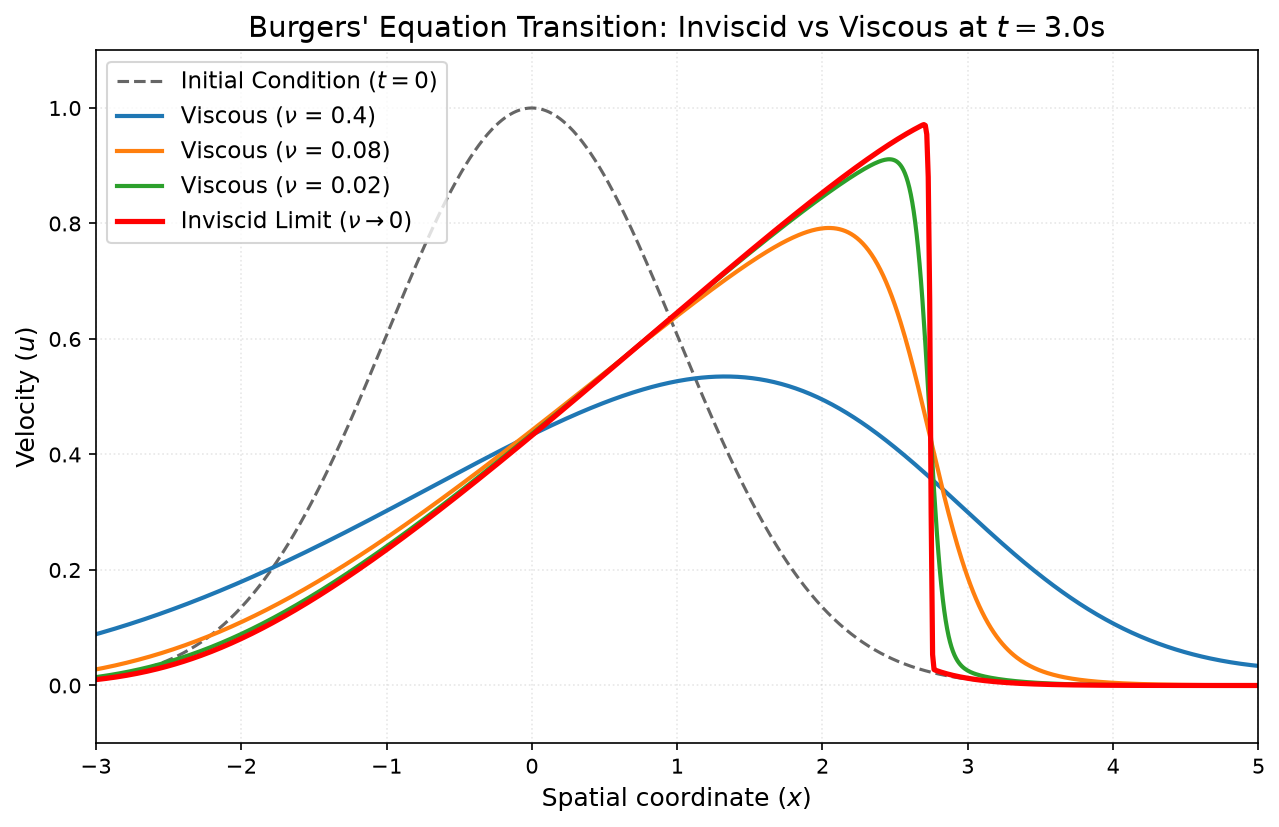

In [126]:
#| code-summary: "Burgers' Equation: Inviscid vs Viscous"
#| echo: false
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

def burgers_flux(u):
    return 0.5 * u ** 2

def solve_burgers(u_init, Dx, T, nu):
    """
    Solve the viscous Burgers equation: d_t u + d_x (0.5 u^2) = nu * d_xx u
    Uses periodic boundary conditions.
    """
    u = u_init.clone()
    t = 0.0
    
    while t < T:
        # Dynamic dt calculation based on CFL (convection + diffusion)
        max_vel = torch.max(torch.abs(u)).item()
        dt_conv = 0.4 * Dx / (max_vel + 1e-8)
        
        if nu > 0:
            dt_diff = 0.4 * (Dx ** 2) / (2.0 * nu)
            dt = min(dt_conv, dt_diff)
        else:
            dt = dt_conv
            
        # Check to not exceed final time T
        if t + dt > T:
            dt = T - t
            
        # 1. CONVECTIVE FLUX (Rusanov / Local Lax-Friedrichs)
        # Use circular padding to respect periodicity
        u_pad = F.pad(u[None, :], (1, 1), mode='circular')[0]
        u_L = u_pad[:-1]
        u_R = u_pad[1:]
        
        # Maximum local propagation speed at interface
        lmbda = torch.max(torch.abs(u_L), torch.abs(u_R))
        
        # Rusanov numerical flux
        flux = 0.5 * (burgers_flux(u_L) + burgers_flux(u_R)) - 0.5 * lmbda * (u_R - u_L)
        
        # Divergence of convective flux
        rhs_conv = -(flux[1:] - flux[:-1]) / Dx
        
        # 2. DIFFUSION TERM (Central Differences)
        if nu > 0:
            rhs_diff = nu * (u_pad[2:] - 2.0 * u_pad[1:-1] + u_pad[:-2]) / (Dx ** 2)
        else:
            rhs_diff = 0.0
            
        # Explicit update
        u = u + dt * (rhs_conv + rhs_diff)
        t += dt
        
    return u

# --- SIMULATION PARAMETERS ---
L = 10.0
N = 1000
Dx = L / (N-1)
T_final = 1.5 * 2  # Time sufficient for shock formation

x = torch.linspace(-L/2, L/2, N)
# Initial condition: classical Gaussian
u_zero = torch.exp(-0.5 * x**2)

# Diffusion levels to test
nu_values = [0.4, 0.08, 0.02]

# --- COMPUTE SOLUTIONS ---
results = {}

# 1. Compute viscous case for various nu
for nu in nu_values:
    def solve_burgers_fixed(u_init, Dx, T, nu):
        u = u_init.clone()
        t = 0.0

        while t < T:
            max_vel = torch.max(torch.abs(u)).item()
            dt_conv = 0.4 * Dx / (max_vel + 1e-8)
            dt = min(dt_conv, 0.4 * (Dx ** 2) / (2.0 * nu)) if nu > 0 else dt_conv

            if t + dt > T:
                dt = T - t

            u_pad = F.pad(u[None, :], (1, 1), mode='circular')[0]
            u_L = u_pad[:-1]
            u_R = u_pad[1:]

            lmbda = torch.max(torch.abs(u_L), torch.abs(u_R))
            flux = 0.5 * (burgers_flux(u_L) + burgers_flux(u_R)) - 0.5 * lmbda * (u_R - u_L)
            rhs_conv = -(flux[1:] - flux[:-1]) / Dx

            if nu > 0:
                rhs_diff = nu * (u_pad[2:] - 2.0 * u_pad[1:-1] + u_pad[:-2]) / (Dx ** 2)
            else:
                rhs_diff = 0.0

            u = u + dt * (rhs_conv + rhs_diff)
            t += dt

        return u

    results[rf'Viscous ($\nu$ = {nu})'] = solve_burgers_fixed(u_zero, Dx, T_final, nu)

# 2. Compute inviscid limit (nu = 0)
results[r'Inviscid Limit ($\nu \to 0$)'] = solve_burgers(u_zero, Dx, T_final, nu=0.0)

# --- PLOTTING ---
plt.figure(figsize=(10, 6), dpi=150)

# Plot initial condition
plt.plot(x.numpy(), u_zero.numpy(), label=r'Initial Condition ($t=0$)', color='black', linestyle='--', alpha=0.6)

# Color palette for viscosity (from most diffused to steepest)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for (label, u_sol), color in zip(list(results.items())[:-1], colors):
    plt.plot(x.numpy(), u_sol.numpy(), label=label, color=color, linewidth=2)

# Plot inviscid limit (highlighted in red to show pure shock)
plt.plot(x.numpy(), results[r'Inviscid Limit ($\nu \to 0$)'].numpy(), 
         label=r'Inviscid Limit ($\nu \to 0$)', color='red', linewidth=2.5, linestyle='-')

plt.title(rf"Burgers' Equation Transition: Inviscid vs Viscous at $t = {T_final}\mathrm{{s}}$", fontsize=14)
plt.xlabel(r"Spatial coordinate ($x$)", fontsize=12)
plt.ylabel(r"Velocity ($u$)", fontsize=12)
plt.grid(True, alpha=0.3, linestyle=':')
plt.xlim(-3, 5)  # Zoom on wave region to see shock clearly
plt.ylim(-0.1, 1.1)
plt.legend(fontsize=11, loc='upper left')

# Save for presentation
plt.savefig("burgers_comparison.png", bbox_inches='tight')
plt.show()


Simulating Model 1: Jin-Xin...
Simulating Model 2: Burgers with Chapman-Enskog Viscosity...
Simulating Model 3: Burgers with Classical Viscosity (nu = eps*a)...
Simulating Model 4: Inviscid Burgers (nu = 0)...


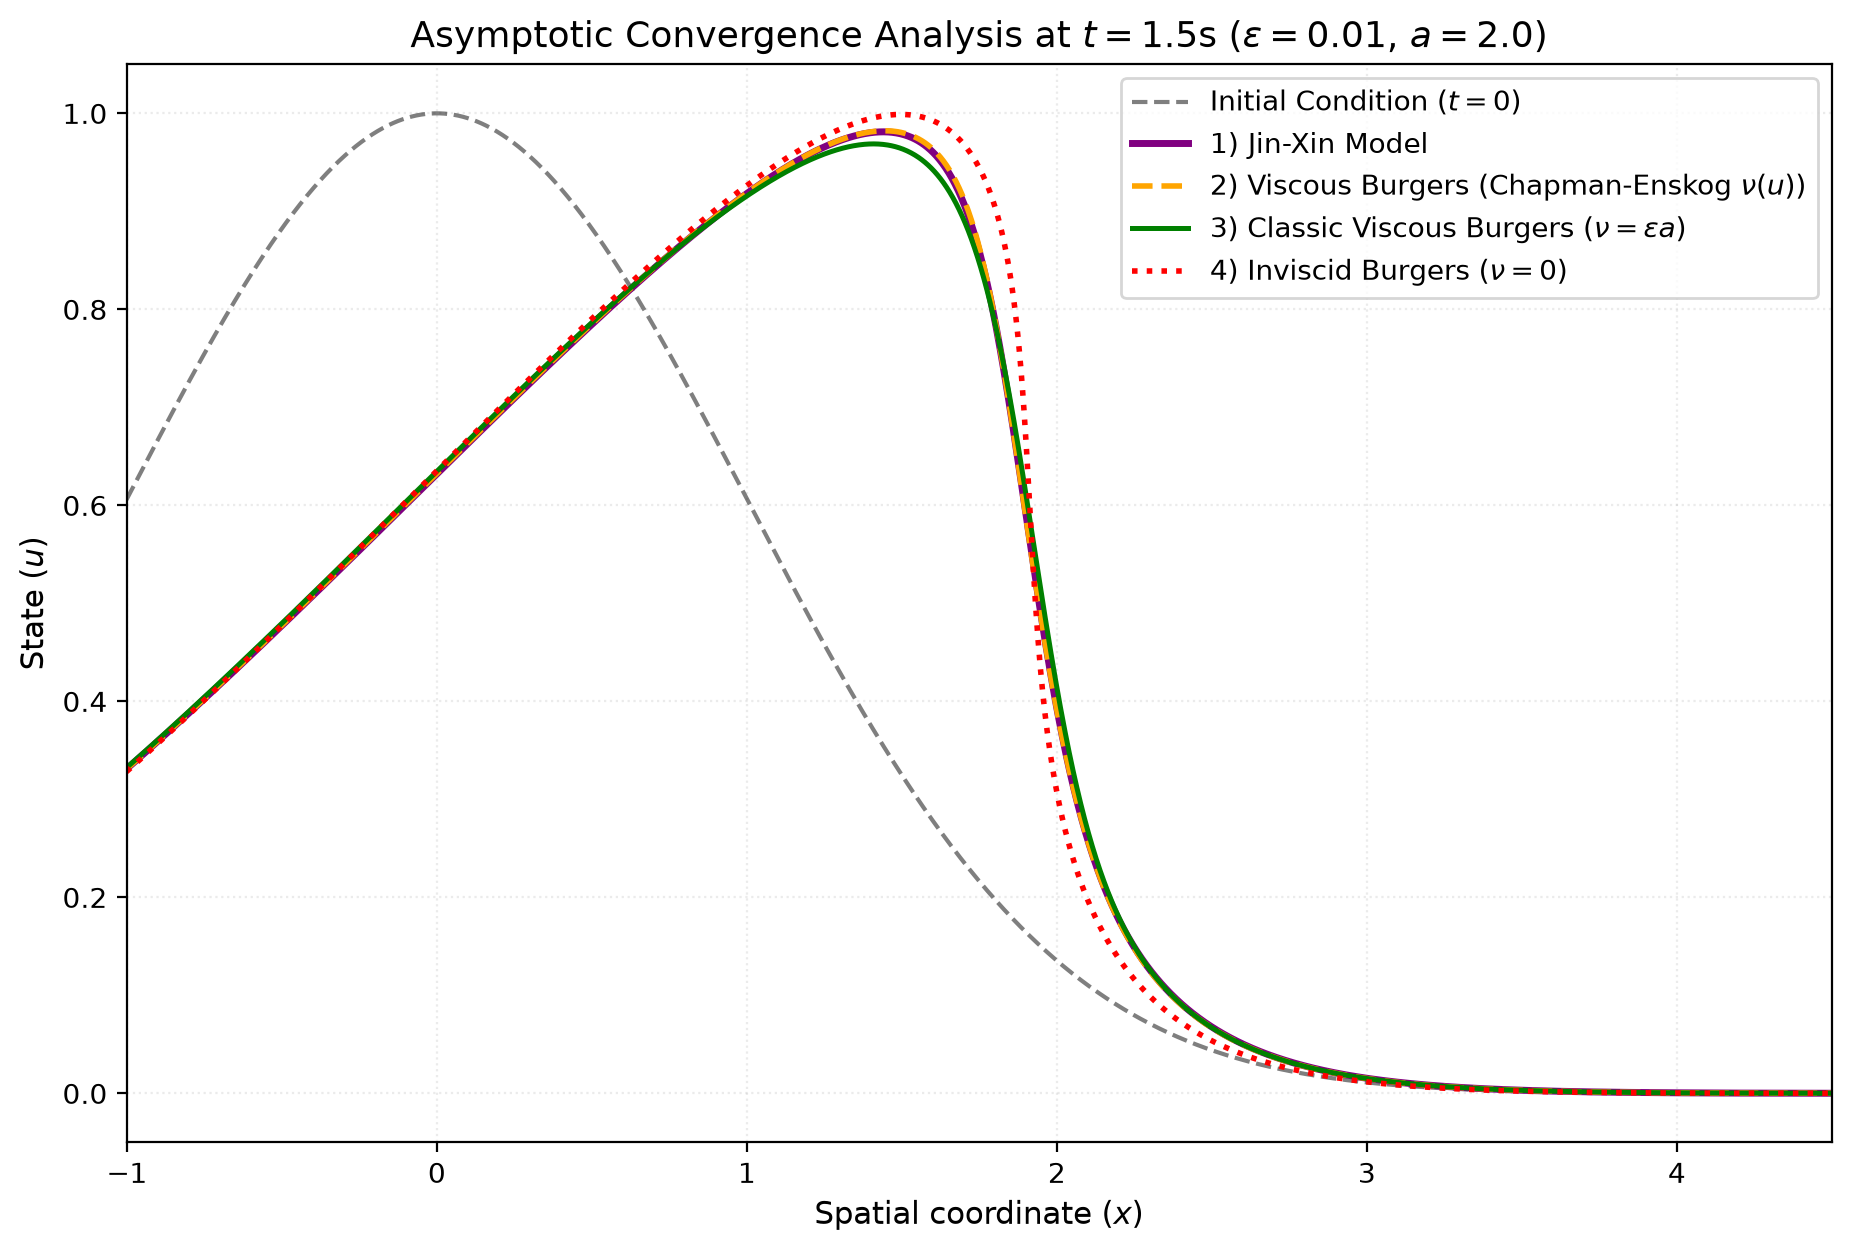

In [127]:
#| code-summary: "Jin-Xin Model vs Burgers' Equation"
#| echo: false
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

# --- FLUX FUNCTIONS ---
def f(u):
    return 0.5 * u ** 2

def f_prime(u):
    return u

# --- 1. JIN-XIN SOLVER (COMPLETE MODEL) ---
def jin_xin_step(u, v, dt, Dx, eps, a):
    u_pad = F.pad(u[None, :], (1, 1), mode='circular')[0]
    v_pad = F.pad(v[None, :], (1, 1), mode='circular')[0]
    
    u_L, u_R = u_pad[:-1], u_pad[1:]
    v_L, v_R = v_pad[:-1], v_pad[1:]
    sqrt_a = sqrt(a)
    
    # Rusanov fluxes for coupled system
    v_flux  = 0.5 * (v_L + v_R) - 0.5 * sqrt_a * (u_R - u_L)
    au_flux = 0.5 * a * (u_L + u_R) - 0.5 * sqrt_a * (v_R - v_L)
    
    difv = (v_flux[1:] - v_flux[:-1]) / Dx
    adifu = (au_flux[1:] - au_flux[:-1]) / Dx
    
    # IMEX advancement
    u_next = u - dt * difv
    v_next = (eps * v - eps * dt * adifu + dt * f(u_next)) / (eps + dt)
    
    return u_next, v_next

def solve_jin_xin(u_init, Dx, T, eps, a):
    u = u_init.clone()
    v = f(u) # Start from local equilibrium v = f(u)
    t = 0.0
    dt = 0.4 * Dx / sqrt(a)
    
    while t < T:
        if t + dt > T: dt = T - t
        u, v = jin_xin_step(u, v, dt, Dx, eps, a)
        t += dt
    return u

# --- 2, 3, 4. GENERAL BURGERS SOLVER (CONVECTION + RIGOROUS DIFFUSION) ---
def solve_burgers_general(u_init, Dx, T, eps, a, mode='inviscid'):
    u = u_init.clone()
    t = 0.0
    
    while t < T:
        max_vel = torch.max(torch.abs(u)).item()
        dt_conv = 0.4 * Dx / (max_vel + 1e-8)
        
        # Calculate dt for diffusive stability
        if mode == 'inviscid':
            dt = dt_conv
        else:
            nu_max = eps * a
            dt_diff = 0.4 * (Dx ** 2) / (2.0 * nu_max)
            dt = min(dt_conv, dt_diff)
            
        if t + dt > T: dt = T - t
        
        # Rusanov convective flux
        u_pad = F.pad(u[None, :], (1, 1), mode='circular')[0]
        u_L, u_R = u_pad[:-1], u_pad[1:]
        lmbda = torch.max(torch.abs(u_L), torch.abs(u_R))
        flux_conv = 0.5 * (f(u_L) + f(u_R)) - 0.5 * lmbda * (u_R - u_L)
        rhs_conv = -(flux_conv[1:] - flux_conv[:-1]) / Dx
        
        # Diffusive term
        rhs_diff = 0.0
        if mode == 'classic':
            nu_const = eps * a
            rhs_diff = nu_const * (u_pad[2:] - 2.0 * u_pad[1:-1] + u_pad[:-2]) / (Dx ** 2)
            
        elif mode == 'chapman':
            # Variable viscosity: nu(u) = eps * (a - u^2)
            nu = eps * (a - u**2)
            nu_pad = F.pad(nu[None, :], (1, 1), mode='circular')[0]
            
            # Compute gradients and viscosities at cell interfaces (i+1/2)
            grad_u = (u_pad[1:] - u_pad[:-1]) / Dx
            nu_face = 0.5 * (nu_pad[1:] + nu_pad[:-1])
            
            # Conservative diffusive flux
            diff_flux = nu_face * grad_u
            rhs_diff = (diff_flux[1:] - diff_flux[:-1]) / Dx
            
        u = u + dt * (rhs_conv + rhs_diff)
        t += dt
        
    return u

# --- SIMULATION SETUP ---
L = 10.0
N = 4000         # Very fine grid (Dx = 0.0025) to perfectly resolve eps = 0.001
Dx = L / (N-1)
T_final = 1.5    # Time of shock formation
eps = 0.01
a = 2.0          # Sub-characteristic condition satisfied (a > 1^2)

x = torch.linspace(-L/2, L/2, N)
u_zero = torch.exp(-0.5 * x**2)

# --- MODEL EXECUTION ---
print("Simulating Model 1: Jin-Xin...")
u_jinxin = solve_jin_xin(u_zero, Dx, T_final, eps, a)

print("Simulating Model 2: Burgers with Chapman-Enskog Viscosity...")
u_chapman = solve_burgers_general(u_zero, Dx, T_final, eps, a, mode='chapman')

print("Simulating Model 3: Burgers with Classical Viscosity (nu = eps*a)...")
u_classic = solve_burgers_general(u_zero, Dx, T_final, eps, a, mode='classic')

print("Simulating Model 4: Inviscid Burgers (nu = 0)...")
u_inviscid = solve_burgers_general(u_zero, Dx, T_final, eps, a, mode='inviscid')

# --- PLOTTING ---
plt.figure(figsize=(11, 7), dpi=200)

plt.plot(x.numpy(), u_zero.numpy(), label=r'Initial Condition ($t=0$)', color='black', linestyle='--', alpha=0.5)
plt.plot(x.numpy(), u_jinxin.numpy(), label=r'1) Jin-Xin Model', color='purple', linewidth=2.5)
plt.plot(x.numpy(), u_chapman.numpy(), label=r'2) Viscous Burgers (Chapman-Enskog $\nu(u)$)', color='orange', linestyle='--', linewidth=2)
plt.plot(x.numpy(), u_classic.numpy(), label=r'3) Classic Viscous Burgers ($\nu = \varepsilon a$)', color='green', linewidth=1.8)
plt.plot(x.numpy(), u_inviscid.numpy(), label=r'4) Inviscid Burgers ($\nu = 0$)', color='red', linestyle=':', linewidth=2)

plt.title(rf"Asymptotic Convergence Analysis at $t = {T_final}\mathrm{{s}}$ ($\varepsilon = {eps}$, $a = {a}$)", fontsize=13)
plt.xlabel(r"Spatial coordinate ($x$)", fontsize=11)
plt.ylabel(r"State ($u$)", fontsize=11)
plt.grid(True, alpha=0.25, linestyle=':')
plt.xlim(-1, 4.5)  # Zoom on shock front
plt.ylim(-0.05, 1.05)
plt.legend(fontsize=10, loc='upper right')

plt.savefig("asymptotic_comparison.png", bbox_inches='tight')
plt.show()


## Other Works <a name="other-works"></a>

In the literature, we find two main classes of schemes to solve the Jin-Xin model: classical numerical schemes and Physics-Informed Neural Networks (PINNs). Here are the state-of-the-art examples for both approaches:

- **Implicit-Explicit (IMEX) schemes:** These methods treat the non-stiff differential part explicitly (avoiding costly nonlinear system inversions) and the stiff relaxation term implicitly. A properly designed IMEX scheme possesses the Asymptotic-Preserving (AP) property: it transitions seamlessly to a consistent and stable macroscopic solver for the inviscid Burgers' equation as $\varepsilon \to 0$, without suffering from restrictive CFL constraints.

- **RelaxNN (Relaxation Neural Networks):** Representing the current state-of-the-art for hyperbolic relaxation in SciML, RelaxNN frameworks fundamentally reformulate the PDE residuals to bypass the stiffness. Instead of dividing by $\varepsilon$, the residuals are scaled appropriately (e.g., multiplying the governing equations by $\varepsilon$ or reformulating the loss to separate the equilibrium penalty from the flux gradient). This balancing act equalizes the backpropagated gradients, preventing the Neural Tangent Kernel (NTK) from diverging and allowing the network to uniformly converge to the correct shock profile independently of the magnitude of the relaxation time.

### IMEX Methods

A first-order IMEX method for the Jin-Xin system can be described as follows:
$$
    \begin{cases}
        \frac{u^{n+1} - u^{n}}{\Delta t} + \partial_x v^{n} = 0
        \\
        \frac{v^{n+1}-v^{n}}{\Delta t} + a \partial_x u^{n} = -\frac1\varepsilon \left(v^{n+1}-f(u^{n+1})\right)
    \end{cases}
$$
In particular, we apply an explicit scheme for the first equation (transport term) to compute $u^{n+1}$, and then an implicit scheme for the second equation to compute $v^{n+1}$ evaluating the stiff relaxation term at the new time step.

**Drawbacks:**
- Designing high-order IMEX Runge-Kutta methods that are rigorously AP and uniformly stable is algebraically complex.

### RelaxNN Architecture

The standard approach for a PINN requires the formulation of a physical loss function. For the Jin-Xin relaxation equation, it contains the following residual:

$$\mathcal{R}_{standard} = \partial_t v + a \partial_x u + \frac{1}{\varepsilon} \left(v-f(u)\right)$$

However, if $\varepsilon \ll 1$, the training process is completely dominated by the penalty term $\frac{1}{\varepsilon}(v-f(u))$. The optimizer ignores the differential operators, severely degrading the performance of the training and leading to the so-called Gradient Pathology.

To overcome this, the current state-of-the-art relies on a Macro-Micro decomposition, employing two separate neural networks (or two distinct outputs). We define the perturbation $w$ as follows:

$$v = f(u) - \varepsilon\left(\partial_t v + a \partial_x u\right) = f(u) + \varepsilon w$$

where $w$ is another function that describes the microscopic perturbation of $v$ from the local equilibrium flux $f(u)$.

Instead of estimating $u$ and $v$ directly, we estimate $u$ and $w$ to reconstruct the original variables. We can rewrite the Jin-Xin model using these new coordinates:

$$\begin{cases}
        \begin{aligned}
            0 &= \partial_t u + \partial_x v \\
              &= \partial_t u + \partial_x \left(f(u) + \varepsilon w\right) \\
              &= \partial_t u + \partial_x f(u) + \varepsilon \partial_x w
        \end{aligned}
        \\[10pt]
        \begin{aligned}
            -w &= - \frac{1}{\varepsilon}\left(f(u) + \varepsilon w - f(u)\right) \\
               &= - \frac{1}{\varepsilon}\left(v - f(u)\right) \\
               &= \partial_t v + a\partial_x u \\
               &= \partial_t \left(f(u) + \varepsilon w\right) + a\partial_x u \\
               &= \partial_t f(u) + \varepsilon \partial_t w + a\partial_x u
        \end{aligned}
    \end{cases}$$

The final Macro-Micro model becomes:

$$\begin{cases}
        \partial_t u + \partial_x f(u) + \varepsilon \partial_x w = 0
        \\[6pt]
        w + \partial_t f(u) + a\partial_x u + \varepsilon \partial_t w = 0
    \end{cases}$$

This represents an APNN (Asymptotic-Preserving Neural Network) formulation. Indeed, as $\varepsilon \to 0$, the singularity $\frac{1}{\varepsilon}$ has completely disappeared from the loss function, and we perfectly recover the asymptotic limit:
$$
    \begin{cases}
        \partial_t u + \partial_x f(u) = 0 & (\textrm{Inviscid Burgers' Equation})
        \\[6pt]
        w = -\left(\partial_t f(u) + a\partial_x u\right) & (\textrm{Micro Equation})
    \end{cases}
$$

**Drawbacks:**

- **Computational Cost:** Training a PINN involves minimizing a highly non-convex loss function over many epochs, making it significantly more computationally expensive than the sequential time-stepping of a classical numerical scheme.

- **Residual Spectral Bias:** Although RelaxNN solves the gradient pathology, neural networks inherently struggle to represent perfect mathematical discontinuities (like a pure Heaviside step at $\varepsilon=0$). The network output will typically exhibit a slightly smoothed shock profile.

- **Hyperparameter Sensitivity:** Balancing the loss weights between the macroscopic network, microscopic network, and boundary/initial conditions requires meticulous tuning.

### Summary

To highlight the structural differences between these state-of-the-art approaches, we compare them across several critical dimensions:


| Feature | IMEX | RelaxNN |
| --- | --- | --- |
| Asymptotic-Preserving (AP) | Requires highly complex algebraic design to satisfy stiff accuracy conditions (e.g., specific Butcher tableaus). | Naturally and elegantly achieved through architectural design (Macro-Micro analytical splitting). |
| Computational Cost | Extremely fast and efficient for a single forward simulation. | Expensive and time-consuming to train. However, once trained, inference is exceptionally fast and allows continuous evaluations. |
| Accuracy & Shockwaves | High accuracy relies on advanced shock-capturing limiters (e.g., WENO, TVD). Prone to numerical diffusion or dispersion at low resolution. | Provides a globally continuous analytical approximation. Suffers from spectral bias, rendering shocks slightly smoother than classical schemes but inherently avoiding Gibbs oscillations. |
| Grid Dependence   | Grid-dependent. Subjected to CFL constraints (though relaxed by implicit terms). | Completely mesh-free. The solution can be evaluated at any arbitrary, continuous spatiotemporal coordinate. |
| Dimensionality & Scaling      | Suffers drastically from the "curse of dimensionality". | Scales exceptionally well to high-dimensional PDEs and inverse problems (parameter estimation). |

### Remarks on High-Dimensionality

A notable advantage of applying PINN-based approaches like RelaxNN is their scalability to higher dimensions. The multi-dimensional Jin-Xin model is defined as:
$$
    \begin{cases}
        \partial_t u + \nabla_x \cdot v = 0
        \\
        \partial_t v + D \nabla_x u = -\frac1\varepsilon\left(v - f(u)\right)
    \end{cases}
$$
where $x \in \mathbb{R}^n$, the state variable is $u: \mathbb{R}^n \times \mathbb{R}^+ \to \mathbb{R}$, the flux variable is a vector field $v: \mathbb{R}^n \times \mathbb{R}^+ \to \mathbb{R}^n$, and $f(u) = (f_1(u), \dots, f_n(u))^T$.
To ensure strict hyperbolicity and physical stability, $D \in \mathbb{R}^{n\times n}$ must be a diagonal positive-definite matrix $D = \text{diag}(d_1, \dots, d_n)$ satisfying the sub-characteristic condition for each spatial dimension:
$$d_i > (f_i'(u))^2 \quad \text{for } i = 1, \dots, n$$

The PDE of the RelaxNN will be:
$$
\begin{align*}
    &\begin{cases}
        \partial_t u + \nabla_x \cdot \left(f(u) + \varepsilon w\right) = 0
        \\
        \partial_t \left(f(u) + \varepsilon w\right) + D \nabla_x u = -\frac1\varepsilon\left(\left(f(u) + \varepsilon w\right) - f(u)\right)
    \end{cases}\\
    &\begin{cases}
        \partial_t u + \nabla_x \cdot f(u) = -\varepsilon\nabla_x \cdot w
        \\
        w = -\partial_t f(u) - \varepsilon \partial_t w - D \nabla_x u
    \end{cases}
\end{align*}
$$
with limit:
$$
    \begin{cases}
        \partial_t u + \nabla_x \cdot f(u) = 0
        \\
        w = -\partial_t f(u) - D \nabla_x u
    \end{cases}
$$

## Implementation

### IMEX 1D

In this implementation we use the Rusanov flux for the computation of $\partial_x u$ and $\partial_x v$. For this purpose, we rewrite the Jin-Xin model as follows:
$$
    \partial_t U + \partial_x F(U) = h(U)
$$
where: $U=(u,v)$, $F(U)=(v,au)$, $h(U)=\left(0,-\frac1\varepsilon\left(v-f(u)\right)\right)$.

The Rusanov flux computes an intermediate state and then we use it to compute the derivative of $U$:
$$
    \begin{align*}
        &R_{i} = \frac{F(U)_{i-\frac12}+F(U)_{i+\frac12}}{2} - \sqrt{a}\frac{U_{i+\frac12}-U_{i-\frac12}}{2} \\&\quad
        \begin{cases}
            r_{i}^{(1)} = \frac{v_{i-\frac12}+v_{i+\frac12}}{2} - \sqrt{a}\frac{u_{i+\frac12}-u_{i-\frac12}}{2}
            \\
            r_{i}^{(2)} = a\frac{u_{i-\frac12}+u_{i+\frac12}}{2} - \sqrt{a}\frac{v_{i+\frac12}-v_{i-\frac12}}{2}
        \end{cases} \quad\forall i=\frac12,\frac32,\ldots \\[2ex]
        &\left(\partial_x F(U)\right)_{k} = \frac{R_{k+\frac12}-R_{k-\frac12}}{\Delta x} \\&\quad
        \begin{cases}
            \left(\partial_x v\right)_{k} = \frac{r_{k-\frac12}^{(1)}+v_{k+\frac12}^{(1)}}{\Delta x}
            \\
            \left(\partial_x au\right)_{k} = \frac{r_{k-\frac12}^{(2)}+v_{k+\frac12}^{(2)}}{\Delta x}
        \end{cases} \quad\forall k=1,2,\ldots
    \end{align*}
$$
We use this approximation to solve the step:
$$
\begin{align*}
    &\begin{cases}
        \frac{u^{t+1}-u^{t}}{\Delta t} + \left(\partial_x v^t\right) = 0
        \\
        \frac{v^{t+1}-v^{t}}{\Delta t} + \left(\partial_x au^t\right) = -\frac1\varepsilon\left(v^{t+1}-f(u^{t+1})\right)
    \end{cases} \\\implies&
    \begin{cases}
        u^{t+1} = u^t - \Delta t\left(\partial_x v^t\right)
        \\
        v^{t+1} = \frac{\varepsilon}{\varepsilon+\Delta t}\left(v^{t}-\Delta t\left(\partial_x au^t\right)\right) + \frac{\Delta t}{\varepsilon+\Delta t}f(u^{t+1})
    \end{cases}
\end{align*}
$$

In [1]:
#| code-summary: "import libraries"
from math import sqrt
import torch
from torch import nn
from torch.nn import functional as F
import numpy as np
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML, display
import diffutils as dfu
from typing import Callable, Any
import os

In [2]:
#| code-summary: "Functions"
def f(u: torch.Tensor, d: int) -> torch.Tensor:
    """u has shape (B,)
    f(u) has shape (B, d)"""
    r = 0.5 * u ** 2
    return torch.stack([r] + [torch.zeros_like(r)] * (d - 1), dim=-1)
def df(u: torch.Tensor, d: int) -> torch.Tensor:
    """u has shape (B,)
    df(u) has shape (B, d)"""
    return torch.stack([u] + [torch.zeros_like(u)] * (d - 1), dim=-1)

In [131]:
#| code-summary: "IMEX scheme for 1D Jin-Xin relaxation system"
def compute_fluxes(u, v, a, Dx):
    sqrt_a = sqrt(a)
    
    u_pad = F.pad(u[None, :], (1,1), mode='constant')[0]
    v_pad = F.pad(v[None, :], (1,1), mode='constant')[0]
    
    u_L = u_pad[:-1]
    u_R = u_pad[1:]
    v_L = v_pad[:-1]
    v_R = v_pad[1:]
    
    v_flux  = 0.5 * (v_L + v_R) - 0.5 * sqrt_a * (u_R - u_L)
    au_flux = 0.5 * a * (u_L + u_R) - 0.5 * sqrt_a * (v_R - v_L)
    
    difv = (v_flux[1:] - v_flux[:-1]) / Dx
    adifu = (au_flux[1:] - au_flux[:-1]) / Dx
    
    return adifu, difv

def imex_step(u, v, Dt, Dx, eps, a):
    adifu, difv = compute_fluxes(u, v, a, Dx)
    
    # explicit step: u is updated by the derivatives of v
    u_next = u - Dt * difv
    
    # implicit step: v relaxes towards f(u_next)
    v_next = (eps * v - eps * Dt * adifu + Dt * f(u_next, 1)[:,0]) / (eps + Dt)
    
    return u_next, v_next

# --- SETUP ---
L: float = 2.0   # Spatial domain length
T: float = 1.0    # Final time
N: int = 5000    # Number of spatial points
Dx: float = L / (N-1)
a: float = 1.1    # Sub-characteristic condition: a > u^2. Since u max = 1, a=1.1 is safe.

# 1D Courant-Friedrichs-Lewy Condition
Dt: float = Dx / sqrt(a)
eps: float = 0.005
steps: int = int(T / Dt)

x: torch.Tensor = torch.linspace(-L/2, L/2, N)
u: torch.Tensor = -torch.sin(torch.pi*x)  # Shape: (N,)
v: torch.Tensor = f(u, 1)[:, 0]  # Shape: (N,)

u_init_np = u.squeeze().numpy()
v_init_np = v.squeeze().numpy()

u_history = np.empty((steps, N), dtype=np.float32)
v_history = np.empty((steps, N), dtype=np.float32)

for n in range(steps):
    u, v = imex_step(u, v, Dt, Dx, eps, a)
    u_history[n] = u.cpu().numpy()
    v_history[n] = v.cpu().numpy()

In [132]:
#| echo: false
#| code-summary: "animation in html"
"""
fig, ax = plt.subplots(figsize=(8, 4.5))
lineu_init, = ax.plot([], [], label=r"initial $u$", lw=1, color='black', ls='--')
linev_init, = ax.plot([], [], label=r"initial $v$", lw=1, color='gray', ls='--')
lineu, = ax.plot([], [], label=r"$u$", lw=2, color='blue')
linefu, = ax.plot([], [], label=r"$f(u)$", lw=1, color='green', ls=':')
linev, = ax.plot([], [], label=r"$v$", lw=2, color='orange')
title = ax.text(0.5, 1.02, "", transform=ax.transAxes, ha="center")
ax.set_xlim(-L/2, L/2)
ax.set_ylim(-1, 1)
ax.set_xlabel("x")
ax.set_ylabel(r"$u(x,t), v(x,t)$")
ax.legend()
ax.grid(True, alpha=0.3)

fps = 30
frames = fps * T
ratio = max(len(u_history), frames) / frames
Dt = Dt * ratio

x_np = x.numpy()
u_history = u_history[::int(ratio),:]  # downsample to match the desired number of frames
v_history = v_history[::int(ratio),:]  # downsample to match the desired number of frames
fu_history = f(torch.from_numpy(u_history).reshape(-1), 1).reshape(u_history.shape).numpy()  # compute f(u) for each frame

def init():
    lineu_init.set_data(x_np, u_init_np)
    linev_init.set_data(x_np, v_init_np)
    lineu.set_data([], [])
    linev.set_data([], [])
    linefu.set_data([], [])
    title.set_text("")
    return lineu, linev, linefu, title

def update(frame):
    lineu.set_data(x_np, u_history[frame])
    linev.set_data(x_np, v_history[frame])
    linefu.set_data(x_np, fu_history[frame])
    title.set_text(rf"time $t = {frame * Dt:.2f}\,\mathrm{{s}}$")
    return lineu, linev, linefu, title

ani = FuncAnimation(
    fig,
    update,
    frames=len(u_history),
    init_func=init,
    interval=Dt*1000,  # interval in milliseconds
    blit=True
)

ani.save("imex_simulation.gif", writer=PillowWriter(fps=fps), dpi=200)
# save each frame as a separate PNG file
#for i in tqdm(range(len(u_history))):
#    update(i)
#    plt.savefig(f".imex_simulation_folder/frame_{i:04d}.png", dpi=200)

plt.close(fig)
"""
pass

<img src="imex_simulation.gif" alt="IMEX Jin-Xin relaxation animation" width="600">

In [133]:
#| code-summary: "IMEX scheme for 2D Jin-Xin relaxation system"
def compute_fluxes_2d(u, v, a, Dx, Dy):
    # u has shape (N, N), v has shape (2, N, N) where the last dimension is for the two velocity components
    sqrt_a = sqrt(a)
    
    u_pad = F.pad(u[None, None, :, :], (1, 1, 1, 1), mode='constant')[0, 0]
    v_pad = F.pad(v.permute(2, 0, 1)[None, :, :, :], (1, 1, 1, 1), mode='constant')[0].permute(1, 2, 0)
    
    u_L_x = u_pad[1:-1, :-1]    # shape (N, N+1)
    u_R_x = u_pad[1:-1, 1:]     # shape (N, N+1)
    v_L_x = v_pad[1:-1, :-1, 0] # shape (N, N+1)
    v_R_x = v_pad[1:-1, 1:, 0]  # shape (N, N+1)
    u_D_y = u_pad[:-1, 1:-1]    # shape (N+1, N)
    u_U_y = u_pad[1:, 1:-1]     # shape (N+1, N)
    v_D_y = v_pad[:-1, 1:-1, 1] # shape (N+1, N)
    v_U_y = v_pad[1:, 1:-1, 1]  # shape (N+1, N)
    
    # X case
    v_flux_x  = 0.5 * (v_L_x + v_R_x) - 0.5 * sqrt_a * (u_R_x - u_L_x)     # shape (N, N+1)
    au_flux_x = 0.5 * a * (u_L_x + u_R_x) - 0.5 * sqrt_a * (v_R_x - v_L_x) # shape (N, N+1)
    # Y case
    w_flux_y  = 0.5 * (v_D_y + v_U_y) - 0.5 * sqrt_a * (u_U_y - u_D_y)     # shape (N+1, N)
    bu_flux_y = 0.5 * a * (u_D_y + u_U_y) - 0.5 * sqrt_a * (v_U_y - v_D_y) # shape (N+1, N)
    
    difv = (v_flux_x[:, 1:] - v_flux_x[:, :-1]) / Dx     # shape (N, N)
    difw = (w_flux_y[1:, :] - w_flux_y[:-1, :]) / Dy     # shape (N, N)
    adifu = (au_flux_x[:, 1:] - au_flux_x[:, :-1]) / Dx  # shape (N, N)
    bdifu = (bu_flux_y[1:, :] - bu_flux_y[:-1, :]) / Dy  # shape (N, N)
    
    return torch.stack((adifu, bdifu), dim=-1), torch.stack((difv, difw), dim=-1)

def imex_step_2d(u, v, Dt, Dx, Dy, eps, a):
    Ddifu, difv = compute_fluxes_2d(u, v, a, Dx, Dy)
    
    # explicit step: u is updated by the divergences in X and Y
    u_next = u - Dt * torch.sum(difv, dim=-1)
    
    # implicit step: v and w relax independently
    fu_next = f(u_next, 2)
    v_next = (eps * v - eps * Dt * Ddifu + Dt * fu_next) / (eps + Dt)
    
    return u_next, v_next

# --- SETUP 2D ---
L: float = 2.0
T: float = 1.0
N: int = 400
Dx: float = L / (N-1)
Dy: float = L / (N-1)
a: float = 1.1     

# 2D Courant-Friedrichs-Lewy Condition
Dt: float = 0.5 * Dx / sqrt(a)
eps: float = 0.03
steps: int = int(T / Dt)

x: torch.Tensor = torch.linspace(-L/2, L/2, N)
y: torch.Tensor = torch.linspace(-L/2, L/2, N)
Y, X = torch.meshgrid(y, x, indexing='ij')
u: torch.Tensor = -torch.sin(torch.pi * X)*torch.cos(torch.pi/2 * Y)  # Shape: (N, N)
v = f(u.reshape(-1), 2).reshape(N, N, 2)  # Shape: (N, N, 2)

u_init_np = u.squeeze().numpy()
v_init_np = v.squeeze().numpy()

u_history = np.empty((steps, N, N), dtype=np.float32)
vel_history = np.empty((steps, N, N, 2), dtype=np.float32)
fu_history = np.empty((steps, N, N, 2), dtype=np.float32)
for n in range(steps):
    u, v = imex_step_2d(u, v, Dt, Dx, Dy, eps, a)
    u_history[n] = u.cpu().numpy()
    vel_history[n] = v.cpu().numpy()
    fu_history[n] = f(u.reshape(-1),2).reshape(N,N,2).cpu().numpy()

r_history = np.linalg.norm(vel_history - fu_history, axis=-1)

In [134]:
#| echo: false
#| code-summary: "animation in html"
#| show-output: false
"""
fps = 30
frames = fps * T
ratio = max(len(u_history), frames) / frames
Dt = Dt * ratio

x_np = x.numpy()
u_history = u_history[::int(ratio),:]  # downsample to match the desired number of frames
r_history = r_history[::int(ratio),:]  # downsample to match the desired number of frames

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
extent = [-L/2, L/2, -L/2, L/2]
max_res = np.max(np.abs(r_history)) 
if max_res == 0: max_res = 1e-5
im_u = ax1.imshow(u_history[0], extent=extent, origin='lower', cmap='viridis', 
                  vmin=-1.0, vmax=1.0, animated=True)
im_r = ax2.imshow(r_history[0], extent=extent, origin='lower', cmap='gray',
                    vmin=0, vmax=max_res, animated=True)
fig.colorbar(im_u, ax=ax1, pad=0.04, label=r"$u(x,y)$")
fig.colorbar(im_r, ax=ax2, pad=0.04, label=r"$v - f(u)$")
ax1.set_title(r"Macro $u$")
ax2.set_title(r"Deviation $\left\|v - f(u)\right\|$")
for ax in (ax1, ax2):
    ax.set_xlabel("x")
    ax.set_ylabel("y")
title = fig.suptitle(r"Time $t = 0.00\,\mathrm{s}$", fontsize=16)
plt.tight_layout(pad=0.5)

def init():
    im_u.set_data(u_history[0])
    im_r.set_data(r_history[0])
    title.set_text(r"Time $t = 0.00\,\mathrm{s}$")
    return im_u, im_r, title

def update(frame):
    im_u.set_data(u_history[frame])
    im_r.set_data(r_history[frame])
    title.set_text(rf"Time $t = {frame * Dt:.2f}\,\mathrm{{s}}$")
    return im_u, im_r, title

ani = FuncAnimation(
    fig,
    update,
    frames=len(u_history),
    init_func=init,
    interval=1000/fps, # Intervallo in millisecondi
    blit=True
)

ani.save("imex_simulation_2D.gif", writer=PillowWriter(fps=fps), dpi=150)
plt.close(fig)
"""
pass

<img src="imex_simulation_2D.gif" alt="IMEX 2D Jin-Xin relaxation animation" width="600">

In [ ]:
#| code-summary: "RelaxNN definitions"
class RelaxNN(nn.Module):
    def __init__(self, d: int):
        super(RelaxNN, self).__init__()
        self.d = d
        self.encoder = nn.Sequential(
            nn.Linear(1+self.d, 64),
            nn.SiLU(),
            nn.Linear(64, 512),
            nn.SiLU(),
            nn.Linear(512, 512),
            nn.SiLU(),
            nn.Linear(512, 512),
            nn.SiLU(),
        )
        self.head_u = nn.Sequential(
            nn.Linear(512, 512),
            nn.Tanh(),
            nn.Linear(512, 1),
            nn.Identity(),
        )
        self.head_w = nn.Sequential(
            nn.Linear(512, 512),
            nn.Tanh(),
            nn.Linear(512, self.d),
            nn.Identity(),
        )

    def forward(self, xt):
        lat_vec = self.encoder(xt)
        u = self.head_u(lat_vec)  # shape (N, 1)
        w = self.head_w(lat_vec)  # shape (N, d)
        return torch.cat([u, w], dim=-1)  # shape (N, 1 + d)

def convection_loss_fn(model: Callable[[torch.Tensor], torch.Tensor], x: torch.Tensor, t: torch.Tensor, eps: float):
    # x has shape (N, d) and t has shape (N,) or (N, 1)
    model_in = torch.cat([t, x], dim=-1)  # shape (N, d + 1)
    jacob = dfu.compute_jacobian(model, model_in)  # shape (N, d+1, d+1)
    
    u_w = model(model_in)  # shape (N, d+1)
    u = u_w[:, 0]  # shape (N,)
    w = u_w[:, 1:]  # shape (N,d)
    
    Dtu_w = jacob[:, :, 0]  # shape (N, d+1)
    Dxu_w = jacob[:, :, 1:]  # shape (N, d+1, d)
    
    Dtu = Dtu_w[:, 0]  # shape (N,)
    Dtw = Dtu_w[:, 1:]  # shape (N, d)
    Dxu = Dxu_w[:, 0]  # shape (N, d)
    Dxw = Dxu_w[:, 1:]  # shape (N, d, d)
    Divxw = torch.einsum('nii->n', Dxw)  # shape (N,)
    df_u = df(u, model.d)  # shape (N, d)
    
    res = Dtu + torch.einsum('ni, ni -> n', df_u, Dxu) + eps * Divxw  # shape (N,)
    # L1 loss for convection residual (regularization-style)
    loss = torch.mean(res.abs())
    
    return loss, res

def flux_loss_fn(model: Callable[[torch.Tensor], torch.Tensor], x: torch.Tensor, t: torch.Tensor, eps: float, a: float):
    # x has shape (N, d) and t has shape (N,) or (N, 1)
    model_in = torch.cat([t, x], dim=-1)  # shape (N, d + 1)
    jacob = dfu.compute_jacobian(model, model_in)  # shape (N, d+1, d+1)
    
    u_w = model(model_in)  # shape (N, d+1)
    u = u_w[:, 0]  # shape (N,)
    w = u_w[:, 1:]  # shape (N,d)
    
    Dtu_w = jacob[:, :, 0]  # shape (N, d+1)
    Dxu_w = jacob[:, :, 1:]  # shape (N, d+1, d)
    
    Dtu = Dtu_w[:, 0]  # shape (N,)
    Dtw = Dtu_w[:, 1:]  # shape (N, d)
    Dxu = Dxu_w[:, 0]  # shape (N, d)
    Dxw = Dxu_w[:, 1:]  # shape (N, d, d)
    Divxw = torch.einsum('nii->n', Dxw)  # shape (N,)
    df_u = df(u, model.d)  # shape (N, d)
    
    res = w + df_u * Dtu[:, None] + a * Dxu + eps * Dtw # shape (N, d)
    # L1 loss for flux residual (regularization-style)
    loss = torch.mean(res.abs())
    
    return loss, res

def IC_loss_fn(model: Callable[[torch.Tensor], torch.Tensor], x: torch.Tensor, eps: float):
    # x has shape (N, 1)
    
    u_w = model(torch.cat([torch.zeros_like(x[:,[0]]), x], dim=-1))  # shape (N, 1+d)
    u = u_w[:, 0]  # shape (N,)
    w = u_w[:, 1:]  # shape (N,d)
    
    v = f(u, model.d) + eps * w
    
    res_u = u - u0(x)  # shape (N,)
    res_v = v - v0(x, model.d)  # shape (N,d)
    
    res = torch.concatenate([res_u[:, None], res_v], dim=-1)  # shape (N, 1 + d)
    # L2 loss for initial condition residual (mainly for training)
    loss_1 = torch.mean(res_u ** 2)
    loss_2 = torch.mean(res_v ** 2)
    loss = torch.mean(res_u ** 2) + torch.mean(res_v ** 2)
    
    return loss, res

def BC_loss_fn(model: Callable[[torch.Tensor], torch.Tensor], x: torch.Tensor, t: torch.Tensor, eps: float):
    # t has shape (N,), x has shape (N, d-1)
    
    # for each boundary, we compute the residuals and losses separately, then sum them up
    losses = []
    for axis in range(model.d):
        for boundary in ['left', 'right']:
            # x_boundary has shape (N, d) with the axis-th component set to a constant value (e.g., -L/2)
            if boundary == 'left':
                x_boundary = torch.empty(x.shape[0], model.d, device=x.device)
                x_boundary[:, [i for i in range(model.d) if i != axis]] = x
                x_boundary[:, axis] = -L/2
            else:
                x_boundary = torch.empty(x.shape[0], model.d, device=x.device)
                x_boundary[:, [i for i in range(model.d) if i != axis]] = x
                x_boundary[:, axis] = L/2
            u_w = model(torch.cat([t, x_boundary], dim=-1))  # shape (N, 1+d)
            u = u_w[:, 0]  # shape (N,)
            w = u_w[:, 1:]  # shape (N,d)
            res_u = u  # shape (N,)
            res_v = f(u, model.d) + eps * w  # shape (N, d)
            losses.append(torch.mean(res_u ** 2) + torch.mean(res_v ** 2))
    
    loss = torch.mean(torch.stack(losses))
    
    return loss


Learning rate reduced to 0.001000 at epoch 4491
Learning rate reduced to 0.000500 at epoch 5146
Learning rate reduced to 0.000250 at epoch 6802
Learning rate reduced to 0.000125 at epoch 7337
Learning rate reduced to 0.000063 at epoch 8576


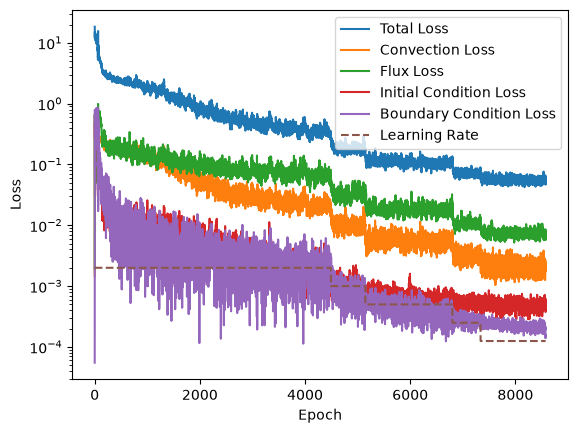

In [ ]:
#| code-summary: "RelaxNN scheme for 1D Jin-Xin relaxation system"
def u0(x: torch.Tensor) -> torch.Tensor:
    return -torch.sin(torch.pi * x[:,0])  # initial condition for u
def v0(x: torch.Tensor, d: int) -> torch.Tensor:
    return f(u0(x), d=d)  # shape (N, d)
model1D = RelaxNN(d=1)

optimizer = torch.optim.Adam(model1D.parameters(), lr=0.002)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=400)

eps = 0.005
a = 1.1
T = 1.0
L = 2.0
# hole size: 0.1, with probability 0.1
Cn_samples = 1510  # 2D space
Fn_samples = 1510  # 2D space
ICn_samples = 105  # 1D space
BCn_samples = 46   # 1D space

Closs_history = []
Floss_history = []
ICloss_history = []
BCloss_history = []
loss_history = []
lr_history = []
while optimizer.param_groups[0]['lr'] > 0.0001:
    optimizer.zero_grad()
    
    # Convection loss
    x = (torch.rand(Cn_samples, 1)*2-1)*L/2  # shape (N, d)
    t = torch.rand(Cn_samples, 1)*T  # shape (N, 1)
    Closs, _ = convection_loss_fn(model1D, x, t, eps)
    
    # Flux loss
    x = (torch.rand(Fn_samples, 1)*2-1)*L/2  # shape (N, d)
    t = torch.rand(Fn_samples, 1)*T  # shape (N, 1)
    Floss, _ = flux_loss_fn(model1D, x, t, eps, a)
    
    # IC loss
    x = (torch.rand(ICn_samples, 1)*2-1)*L/2  # shape (N, d)
    ICloss, _ = IC_loss_fn(model1D, x, eps)
    
    # BC loss
    x = (torch.rand(BCn_samples, 0)*2-1)*L/2  # shape (N, d-1)
    t = torch.rand(BCn_samples, 1)*T  # shape (N, 1)
    BCloss = BC_loss_fn(model1D, x, t, eps)
    
    loss = 10*Closs + Floss + 30*ICloss + BCloss
    
    # regularization losses
    # L2 regularization on model1D.encoder
    model_params = list(model1D.encoder.parameters())
    l2_reg = sum(torch.sum(param ** 2) for param in model_params)
    # L1 regularization on model1D.head_u and model1D.head_w
    model_params_u = list(model1D.head_u.parameters())
    model_params_w = list(model1D.head_w.parameters())
    l1_reg = sum(torch.sum(torch.abs(param)) for param in model_params_u + model_params_w)
    loss += 1e-6 * l2_reg + 1e-6 * l1_reg
    
    loss_history.append(loss.item())
    Closs_history.append(Closs.item())
    Floss_history.append(Floss.item())
    ICloss_history.append(ICloss.item())
    BCloss_history.append(BCloss.item())
    lr_history.append(optimizer.param_groups[0]['lr'])
    loss.backward()
    optimizer.step()
    scheduler.step(loss)
    if optimizer.param_groups[0]['lr'] < lr_history[-1]:
        print(f"Learning rate reduced to {optimizer.param_groups[0]['lr']:.6f} at epoch {len(loss_history)}")
    
plt.plot(loss_history, label='Total Loss')
plt.plot(Closs_history, label='Convection Loss')
plt.plot(Floss_history, label='Flux Loss')
plt.plot(ICloss_history, label='Initial Condition Loss')
plt.plot(BCloss_history, label='Boundary Condition Loss')
plt.plot(lr_history, label='Learning Rate', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
plt.show()

In [ ]:
#| echo: false
#| code-summary: "animation in html"
#| show-output: false
"""
N = 1000
fps = 30
frames = int(fps * T)
Dt = 1/fps

xpin = torch.linspace(-L/2, L/2, N)  # shape (N,)
tpin = torch.linspace(0, T, frames)  # shape (frames,)
t, x = torch.meshgrid(tpin, xpin, indexing='ij')  # shape (frames, N)
xflat = x.flatten()  # shape (frames*N,)
tflat = t.flatten()  # shape (frames*N,)
_, Cres = convection_loss_fn(model1D, xflat.unsqueeze(-1), tflat.unsqueeze(-1), eps)  # shape (frames*N,)
_, Fres = flux_loss_fn(model1D, xflat.unsqueeze(-1), tflat.unsqueeze(-1), eps, a)  # shape (frames*N,)
reshaped_Cres = Cres.reshape(frames, N,)  # shape (frames, N,)
reshaped_Fres = Fres.reshape(frames, N,)  # shape (frames, N,)
uw = model1D(torch.cat([tflat.unsqueeze(-1), xflat.unsqueeze(-1)], dim=-1)).reshape(frames, N, 2)  # shape (frames, N, 2)
u = uw[..., 0]  # shape (frames, N)
w = uw[..., 1]  # shape (frames, N)
v = f(u.reshape(-1), model1D.d)[:,0].reshape(frames,N) + eps * w  # shape (N, N)

# creo 2 subplots per visualizzare u e v separatamente
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
value_min = reshaped_Cres.min().item()
value_max = reshaped_Cres.max().item()
value = max(abs(value_min), abs(value_max))
ax1.imshow(reshaped_Cres.detach().numpy(), extent=[-L/2, L/2, 0, T], vmin=-value, vmax=value, cmap='seismic', origin='lower', aspect='auto')
ax1.set_title('Transport')
cbar1 = fig.colorbar(ax1.imshow(reshaped_Cres.detach().numpy(), extent=[-L/2, L/2, 0, T], vmin=-value, vmax=value, cmap='seismic', origin='lower', aspect='auto'), ax=ax1)
value_min = reshaped_Fres.min().item()
value_max = reshaped_Fres.max().item()
value = max(abs(value_min), abs(value_max))
ax2.imshow(reshaped_Fres.detach().numpy(), extent=[-L/2, L/2, 0, T], vmin=-value, vmax=value, cmap='seismic', origin='lower', aspect='auto')
ax2.set_title('JinXin')
cbar2 = fig.colorbar(ax2.imshow(reshaped_Fres.detach().numpy(), extent=[0, T, -L/2, L/2], vmin=-value, vmax=value, cmap='seismic', origin='lower', aspect='auto'), ax=ax2)
# save figure
fig.savefig("relaxNN_lossplot.png", dpi=300, bbox_inches='tight')
plt.close(fig)

# animation in html
x_np = xpin.detach().numpy()
u_np = u.detach().numpy()
v_np = v.detach().numpy()
u0_np = u0(xpin.unsqueeze(-1)).detach().numpy()
fig, ax = plt.subplots(figsize=(8, 4.5))
lineu, = ax.plot([], [], label=r"$u$", lw=2, color='blue')
linefu, = ax.plot([], [], label=r"$f(u)$", lw=1, color='green', linestyle=':')
linev, = ax.plot([], [], label=r"$v$", lw=2, color='orange')
lineu0, = ax.plot([], [], label=r"$u_0$", lw=1, color='black', linestyle='--')
title = ax.text(0.5, 1.02, "", transform=ax.transAxes, ha="center")
ax.set_xlim(-L/2, L/2)
ax.set_ylim(-1, 1)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$u(x,t)$")
ax.legend()
ax.grid(True, alpha=0.3)

def init():
    lineu.set_data([], [])
    linefu.set_data([], [])
    linev.set_data([], [])
    lineu0.set_data(x_np, u0_np)
    title.set_text("")
    return lineu, linefu, linev, title

def update(frame):
    lineu.set_data(x_np, u_np[frame])
    linefu.set_data(x_np, f(torch.from_numpy(u_np[frame]), model1D.d).reshape(-1).detach().numpy())
    linev.set_data(x_np, v_np[frame])
    title.set_text(rf"Time $t = {frame * Dt:.2f}\,\mathrm{{s}}$")
    return lineu, linefu, linev, title

ani = FuncAnimation(
    fig,
    update,
    frames=frames,
    init_func=init,
    interval=Dt*1000,  # interval in milliseconds
    blit=True
)

ani.save("relaxNN_simulation.gif", writer=PillowWriter(fps=fps), dpi=200)
plt.close(fig)
"""
pass

<img src="relaxNN_lossplot.png" alt="RelaxNN Loss Plot" width="600"><br>

<img src="relaxNN_simulation.gif" alt="RelaxNN Jin-Xin relaxation animation" width="600">

Learning rate reduced to 0.001000 at epoch 3750
Learning rate reduced to 0.000500 at epoch 4455
Learning rate reduced to 0.000250 at epoch 5126
Learning rate reduced to 0.000125 at epoch 6889
Learning rate reduced to 0.000063 at epoch 8070


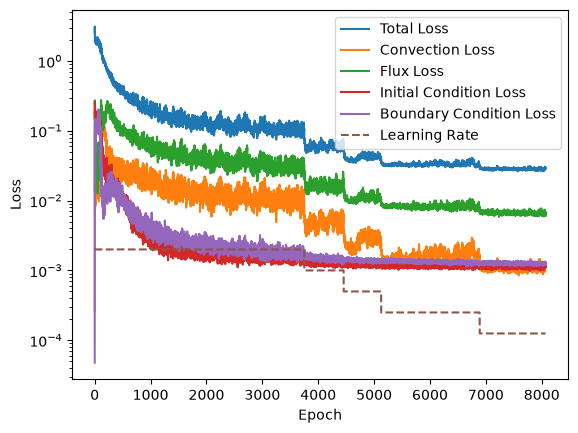

In [ ]:
#| code-summary: "RelaxNN scheme for 2D Jin-Xin relaxation system"
def u0(x: torch.Tensor) -> torch.Tensor:
    return -torch.sin(torch.pi * x[:,0])*torch.cos(torch.pi/2 * x[:,1])  # initial condition for u
def v0(x: torch.Tensor, d: int) -> torch.Tensor:
    return f(u0(x), d=d)  # shape (N, d)

model2D = RelaxNN(d=2)

optimizer = torch.optim.Adam(model2D.parameters(), lr=0.002)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=500) 

eps = 0.03
a = 1.1
T = 1.0
L = 2.0
# hole size: 0.2, with probability 0.1, Coef=0.5
Cn_samples = 2116  # 3D space
Fn_samples = 2116  # 3D space
ICn_samples = 342  # 2D space
BCn_samples = 342  # 2D space

Closs_history = []
Floss_history = []
ICloss_history = []
BCloss_history = []
loss_history = []
lr_history = []
while optimizer.param_groups[0]['lr'] > 0.0001:
    optimizer.zero_grad()
    
    x = (torch.rand(Cn_samples, 2)*2-1)*L/2  # shape (N, d)
    t = torch.rand(Cn_samples, 1)*T  # shape (N, 1)
    Closs, _ = convection_loss_fn(model2D, x, t, eps)
    
    x = (torch.rand(Fn_samples, 2)*2-1)*L/2  # shape (N, d)
    t = torch.rand(Fn_samples, 1)*T  # shape (N, 1)
    Floss, _ = flux_loss_fn(model2D, x, t, eps, a)
    
    x = (torch.rand(ICn_samples, 2)*2-1)*L/2  # shape (N, d)
    ICloss, _ = IC_loss_fn(model2D, x, eps)
    
    x = (torch.rand(BCn_samples, 1)*2-1)*L/2  # shape (N, d-1)
    t = torch.rand(BCn_samples, 1)*T  # shape (N, 1)
    BCloss = BC_loss_fn(model2D, x, t, eps)
    
    # 1D: 10,1,30,1
    # 2D:  5,1,10,1
    loss = 5*Closs + Floss + 10*ICloss + BCloss
    
    # regularization losses
    # L2 regularization on model2D.encoder
    model_params = list(model2D.encoder.parameters())
    l2_reg = sum(torch.sum(param ** 2) for param in model_params)
    # L1 regularization on model2D.head_u and model2D.head_w
    model_params_u = list(model2D.head_u.parameters())
    model_params_w = list(model2D.head_w.parameters())
    l1_reg = sum(torch.sum(torch.abs(param)) for param in model_params_u + model_params_w)
    loss += 1e-6 * l2_reg + 1e-6 * l1_reg
    
    loss_history.append(loss.item())
    Closs_history.append(Closs.item())
    Floss_history.append(Floss.item())
    ICloss_history.append(ICloss.item())
    BCloss_history.append(BCloss.item())
    lr_history.append(optimizer.param_groups[0]['lr'])
    loss.backward()
    optimizer.step()
    scheduler.step(loss)
    if optimizer.param_groups[0]['lr'] < lr_history[-1]:
        print(f"Learning rate reduced to {optimizer.param_groups[0]['lr']:.6f} at epoch {len(loss_history)}")
    
plt.plot(loss_history, label='Total Loss')
plt.plot(Closs_history, label='Convection Loss')
plt.plot(Floss_history, label='Flux Loss')
plt.plot(ICloss_history, label='Initial Condition Loss')
plt.plot(BCloss_history, label='Boundary Condition Loss')
plt.plot(lr_history, label='Learning Rate', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
plt.show()

In [ ]:
#| echo: false
#| code-summary: "load RelaxNN models if they exist"
if os.path.exists("relaxNN_2D_model.pth"):
    eps = 0.03
    a = 1.1
    T = 1.0
    L = 2.0
    model2D = RelaxNN(d=2)
    model2D.load_state_dict(torch.load("relaxNN_2D_model.pth"))
if os.path.exists("relaxNN_1D_model.pth"):
    eps = 0.005
    a = 1.1
    T = 1.0
    L = 2.0
    model1D = RelaxNN(d=1)
    model1D.load_state_dict(torch.load("relaxNN_1D_model.pth"))

In [ ]:
#| echo: false
#| code-summary: "animation in html"
#| show-output: false
"""
with torch.no_grad():
    N = 300
    fps = 30
    nT = int(fps * T)
    Dt = T / nT

    x = torch.linspace(-L/2, L/2, N)  # shape (N,)
    y = torch.linspace(-L/2, L/2, N)  # shape (N,)
    t = torch.linspace(0, T, nT)  # shape (nT,)
    X, Y, T_grid = torch.meshgrid(x, y, t, indexing='ij')  # shape (N, N, nT)
    xflat = torch.stack([X.flatten(), Y.flatten()], dim=-1)  # shape (N*N*nT, 2)
    tflat = T_grid.flatten()  # shape (N*N*nT,)
    uw = model2D(torch.cat([tflat.unsqueeze(-1), xflat], dim=-1)).reshape(N, N, nT, 3)  # shape (N, N, nT, 3)
    u = uw[..., 0]  # shape (N, N, nT)
    r = eps*torch.norm(uw[..., 1:], dim=-1)  # shape (N, N, nT)
    _, Cres = convection_loss_fn(model2D, xflat, tflat.unsqueeze(-1), eps)  # shape (N*N*nT,)
    _, Fres = flux_loss_fn(model2D, xflat, tflat.unsqueeze(-1), eps, a)  # shape (N*N*nT,d)
    reshaped_Cres = Cres.reshape(N, N, nT)  # shape (N, N, nT)
    reshaped_Fres = Fres.reshape(N, N, nT, 2)  # shape (N, N, nT, 2)
    reshaped_Fres = torch.norm(reshaped_Fres, dim=-1)  # shape (N, N, nT)

    x_np = x.numpy()
    u_np = u.cpu().numpy()  # downsample to match the desired number of nT
    r_np = r.cpu().numpy()  # downsample to match the desired number of nT

    # 4 subplots: u, r, Cres, Fres
    # in una griglia 2x2, con u e r in alto, Cres e Fres in basso
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 7))
    extent = [-L/2, L/2, -L/2, L/2]
    max_r = np.max(np.abs(r_np)) 
    max_Cres = np.max(np.abs(reshaped_Cres.cpu().numpy()))
    max_Fres = np.max(np.abs(reshaped_Fres.cpu().numpy()))
    if max_r == 0: max_r = 1e-5
    im_u = ax1.imshow(u_np[0].T, extent=extent, origin='lower', cmap='viridis', 
                    vmin=-1.0, vmax=1.0, animated=True)
    im_r = ax2.imshow(r_np[0].T, extent=extent, origin='lower', cmap='gray',
                        vmin=0, vmax=max_r, animated=True)
    im_Cres = ax3.imshow(reshaped_Cres[:,:,0].T.cpu().numpy(), extent=extent, origin='lower', cmap='seismic',
                        vmin=-max_Cres, vmax=max_Cres, animated=True)
    im_Fres = ax4.imshow(reshaped_Fres[:,:,0].T.cpu().numpy(), extent=extent, origin='lower', cmap='gray',
                        vmin=0, vmax=max_Fres, animated=True)
    fig.colorbar(im_u, ax=ax1, pad=0.04, label=r"$u(x,y)$")
    fig.colorbar(im_r, ax=ax2, pad=0.04, label=r"$v - f(u)$")
    fig.colorbar(im_Cres, ax=ax3, pad=0.04, label=r"$\mathrm{Convective}_{\mathrm{residual}}$")
    fig.colorbar(im_Fres, ax=ax4, pad=0.04, label=r"$\mathrm{Flux}_{\mathrm{residual}}$")
    ax1.set_title(r"Macro $u$")
    ax2.set_title(r"Deviation $\left\|v - f(u)\right\|$")
    ax3.set_title(r"Macro Residual")
    ax4.set_title(r"Micro Residual")
    for ax in (ax1, ax2):
        ax.set_xlabel("x")
        ax.set_ylabel("y")
    title = fig.suptitle(r"Time $t = 0.00\,\mathrm{s}$", fontsize=16)
    plt.tight_layout(pad=0.5)

    def init():
        im_u.set_data(u_np[:,:,0].T)
        im_r.set_data(r_np[:,:,0].T)
        im_Cres.set_data(reshaped_Cres[:,:,0].T.cpu().numpy())
        im_Fres.set_data(reshaped_Fres[:,:,0].T.cpu().numpy())
        title.set_text(r"Time $t = 0.00\,\mathrm{s}$")
        return im_u, im_r, im_Cres, im_Fres, title

    def update(frame):
        im_u.set_data(u_np[:,:,frame].T)
        im_r.set_data(r_np[:,:,frame].T)
        im_Cres.set_data(reshaped_Cres[:,:,frame].T.cpu().numpy())
        im_Fres.set_data(reshaped_Fres[:,:,frame].T.cpu().numpy())
        title.set_text(rf"Time $t = {frame * Dt:.2f}\,\mathrm{{s}}$")
        return im_u, im_r, im_Cres, im_Fres, title

    ani = FuncAnimation(
        fig,
        update,
        frames=nT,
        init_func=init,
        interval=1000/fps, # Intervallo in millisecondi
        blit=True
    )

    ani.save("relaxNN_simulation_2D.gif", writer=PillowWriter(fps=fps), dpi=150)
    plt.close(fig)
"""
pass

<img src="relaxNN_simulation_2D.gif" alt="IMEX 2D Jin-Xin relaxation animation" width="600">

## IMEX-Net

The model IMEX-Net is an hybrid scheme:
- A neural network compute the derivatives $\nabla_x u$ and $\nabla_x\cdot v$.
- The IMEX method takes these results and returns the next state.

Formally, the holes in the grids imply a loss of informations, the role of the neural network is preserve these informations.

In this document, the neural network is a Full Convolutional Network (FCN) that takes in input the grid with values $u,v$ or a them embedding and returns the same grid with the approximations. The Dataset contains grids with respective well-known derivatives but, pay attention: the dataset is noised, in other words for similar grids we can have very differents derivatives.

### DataLoader

For a simple experiment here we fix the quadratic family for the function $u=\frac12\left\|x\right\|_Q^2+\vec{\beta}\cdot x + c$ and the quasi-equilibrium state for the velocity $v$ following the Chapman-Enskog expantion:
$$
v = f(u) - \varepsilon\left(a\textrm{Id}-f'(u)^2\right)\nabla_x u
$$
The spatial divergence of $v$ is:
$$
\begin{align*}
    \nabla_x\cdot v &= \nabla_x\cdot\left(f(u) - \varepsilon\left(a\textrm{Id}-f'(u)^2\right)\nabla_x u\right)\\
    &=\nabla_x\cdot\left(f(u)\right) - \varepsilon\nabla_x\cdot\left(\left(a\textrm{Id}-f'(u)^2\right)\nabla_x u\right)\\
    &=f'(u)\cdot \nabla_x u - \varepsilon\left(\left(\nabla_x\cdot\left(a\textrm{Id}-f'(u)^2\right)\right)\cdot\nabla_x u+\left(a\textrm{Id}-f'(u)^2\right)\cdot\nabla^2_x u\right)\\
    &=f'(u)\cdot \nabla_x u - \varepsilon\left(-\left(\nabla_x\cdot\left(f'(u)^2\right)\right)\cdot\nabla_x u+\left(a\textrm{Id}-f'(u)^2\right)\cdot\nabla^2_x u\right)\\
    &=f'(u)\cdot \nabla_x u - \varepsilon\left(-\left(f'(u)\nabla_x\cdot f'(u)+\nabla_x f'(u)f'(u)\right)\cdot\nabla_x u+\left(a\textrm{Id}-f'(u)^2\right)\cdot\nabla^2_x u\right)\\
    &=f'(u)\cdot \nabla_x u - \varepsilon\left(-\left(f'(u)f''(x)\cdot\nabla_x u+f''(u)f'(u)\cdot\nabla_x u\right)\cdot\nabla_x u+\left(a\textrm{Id}-f'(u)^2\right)\cdot\nabla^2_x u\right)\\
    &=f'(u)\cdot \nabla_x u - \varepsilon\left(-2\left(f'(u)\cdot \nabla_x u \right)\left(f''(u)\cdot\nabla_x u\right)+\left(a\textrm{Id}-f'(u)^2\right)\cdot\nabla^2_x u\right)\\
    &=\left(f'(u)\cdot \nabla_x u\right)\left(1+2\varepsilon\left(f''(u)\cdot\nabla_x u\right)\right)-\varepsilon\left(a\textrm{Id}-f'(u)^2\right)\cdot\nabla^2_x u
\end{align*}
$$
Now, we use the definition of $u$: $\nabla_x u = Qx + \vec{\beta}$ and $\nabla_x^2 u = Q$. So:
$$
    \begin{align*}
    v &= f(u) - \varepsilon\left(a\textrm{Id}-f'(u)^2\right)\left(Qx + \vec{\beta}\right)
    \\
    \nabla_x\cdot v &= \left(f'(u)\cdot \left(Qx + \vec{\beta}\right)\right)\left(1+2\varepsilon\left(f''(u)\cdot\left(Qx + \vec{\beta}\right)\right)\right)-\varepsilon\left(a\textrm{Id}-f'(u)^2\right)\cdot Q
    \end{align*}
$$
Then, for the 1D case we have $f(u)=\frac12u^2$
$$
    \begin{align*}
    v &= \frac12u^2 - \varepsilon\left(a-u^2\right)\left(Qx + \vec{\beta}\right)
    \\
    \nabla_x\cdot v &= u \left(Qx + \vec{\beta}\right)\left(1+2\varepsilon\left(Qx + \vec{\beta}\right)\right)-\varepsilon\left(a-u^2\right) Q
    \end{align*}
$$

The dataloader makes collocation points $$\left(u,v\;\middle|\;\nabla_x u, \nabla_x\cdot v\right)=\left(u,\frac12u^2 - \varepsilon\left(a-u^2\right)\left(Qx + \vec{\beta}\right)\;\middle|\;Qx + \vec{\beta},u \left(Qx + \vec{\beta}\right)\left(1+2\varepsilon\left(Qx + \vec{\beta}\right)\right)-\varepsilon\left(a-u^2\right) Q\right)$$

The neural network (an FCN) interpolates the dataset by using the additivity regularization:
$$
    M(M(U,p),q) = M(U,p+q)
$$
where $M$ is the IMEX-Net model, $U=(u,v)$ and $p,q>0$ are such that $p+q<\Delta T$ the time interval of the scheme.

In [3]:
#| code-summary: "make dataset for 1D Jin-Xin relaxation system"

def get_datapoint(x, q, b, c, eps, a):
    # x has shape (N,D)
    # q has shape (N,)
    # b has shape (N,)
    # c has shape (N,)
    
    # compute u
    u = x**2*q[:,None]/2 + x*b[:,None] + c[:,None]  # shape (N,D)
    # compute grad_u
    grad_u = q[:,None]*x+b[:,None]  # shape (N,D)
    # compute v
    v = 0.5*u**2 - eps*grad_u*(a-u**2)  # shape (N,D)
    # compute div_v
    div_v = u*grad_u*(1+2*eps*grad_u)-eps*(a-u**2)*q[:,None]  # shape (N,D)
    
    return u, v, grad_u, div_v

def make_dataset(N, eps, a, grid_size, L, curvature_variance=1.0, coefficient_variance=1.0, term_variance=1.0, noise_intensity=0.0):
    # N is the number of datapoints
    # eps is the relaxation parameter
    # a is the flux parameter
    # grid_size is the size of the grid in each dimension (integer value)
    # L is the length of the domain in each dimension (float value)
    
    Q0 = torch.randn(N) * curvature_variance/((eps/0.219)**2)
    beta0 = (2*torch.rand(N)-1) * coefficient_variance/(4*eps)
    c = torch.randn(N) * term_variance
    
    # makes grids
    # each row contains values between -L/2, L/2
    x_grid = torch.linspace(-L/2, L/2, grid_size).unsqueeze(0).repeat(N, 1)
    # computes values
    u, v, grad_u, div_v = get_datapoint(x_grid, Q0, beta0, c, eps, a)
    # u has shape (N, grid_size)
    # v has shape (N, grid_size)
    # grad_u has shape (N, grid_size)
    # div_v has shape (N, grid_size)
    
    # add noise to u and v
    Dx = L / (grid_size - 1)
    u = u + noise_intensity * torch.randn_like(u) * Dx
    v = v + noise_intensity * torch.randn_like(v) * Dx
    
    fu = u**2 / 2
    return u, v, fu, grad_u, div_v

influence = 7
Dx = 0.01
grid_size = influence + (influence-1)
u,v,fu,grad_u,div_v = make_dataset(N=100000, eps=0.05, a=1.1, grid_size=grid_size, L=(grid_size-1)*Dx, noise_intensity=1.0)

# make the unique tensor
dsetin = torch.stack([u, v], dim=1)
dsetout = torch.stack([grad_u, div_v], dim=1)

class IMEXNet(nn.Module):
    def __init__(self, INCh: int, OUTCh: int, a: float, eps: float):
        super(IMEXNet, self).__init__()
        self.a = a
        self.eps = eps
        self.FCN = nn.Sequential(
            nn.Conv1d(in_channels=INCh, out_channels=OUTCh, kernel_size=7, padding=3, padding_mode='circular', bias=False),
        )
    def forward(self, u, v, dt):
        x = torch.stack([u, v], dim=1)  
        net_out = self.FCN(x)
        adifu = self.a * net_out[:, 0, :]  
        difv = net_out[:, 1, :]  

        # Explicit step
        u_next = u - dt * difv  
    
        # Implicit step: Usiamo lo stesso identico flusso 1D del dataset
        f_u_next = 0.5 * u_next**2
        v_next = (self.eps * v - self.eps * dt * adifu + dt * f_u_next) / (self.eps + dt)  
    
        return u_next, v_next
    
myModel = IMEXNet(INCh=2, OUTCh=2, a=1.1, eps=0.1)

In [ ]:
#| code-summary: "Training the IMEXNet model"
Dt: float = Dx / sqrt(myModel.a)  # Time step size based on CFL condition
# train the network like interpolator
optimizer = torch.optim.LBFGS(myModel.parameters(), lr=1.0, line_search_fn='strong_wolfe')
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=20)
# dataloader
dataloader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(dsetin, dsetout), batch_size=100000, shuffle=True)
epoch_bar = tqdm(range(100), desc="Training", unit="epoch", colour="blue")

def compute_loss(batch_in, batch_out, dq, dp):
    optimizer.zero_grad()
    
    # 1. Interpolation Loss (sui 7 punti centrali non corrotti da padding)
    output = myModel.FCN(batch_in)
    grid_size = output.shape[2] # 13
    
    # indici 3:10 seleziona esattamente i 7 punti centrali puliti
    output_clean = output[:, :, 3:10]
    target_clean = batch_out[:, :, 3:10]
    interpolation_loss = nn.MSELoss()(output_clean, target_clean)
    
    # 2. Additivity Loss
    u_source, v_source = batch_in[:, 0, :], batch_in[:, 1, :]
    
    u_middle, v_middle = myModel(u_source, v_source, dt=dp)
    u_final1, v_final1 = myModel(u_middle, v_middle, dt=dq)
    u_final2, v_final2 = myModel(u_source, v_source, dt=Dt)
    
    # Comparison only over the central point
    center_idx = grid_size // 2
    u_final1_center = u_final1[:, [center_idx]]
    v_final1_center = v_final1[:, [center_idx]]
    u_final2_center = u_final2[:, [center_idx]]
    v_final2_center = v_final2[:, [center_idx]]
    additivity_loss = nn.MSELoss()(u_final1_center, u_final2_center) + nn.MSELoss()(v_final1_center, v_final2_center)
    
    # 3. Regularization Loss
    reg_loss = 0.0
    for param in myModel.parameters():
        reg_loss += param.abs().sum()
    
    loss = interpolation_loss + additivity_loss / Dt + 1e-6 * reg_loss
    
    return loss

# --- Loop di Training modificato ---
myModel.train()
for epoch in epoch_bar:
    total_batches = len(dataloader)
    for i, (batch_in, batch_out) in enumerate(dataloader):
        
        # Fissiamo i tempi casuali FUORI dalla closure per L-BFGS
        dq = torch.rand(batch_in.shape[0], 1) * Dt  
        dp = torch.rand(batch_in.shape[0], 1) * (Dt - dq)  
        
        def closure():
            optimizer.zero_grad()
            loss = compute_loss(batch_in, batch_out, dq, dp)
            loss.backward()
            return loss

        optimizer.step(closure)
       
        epoch_bar.set_postfix({
            'Batch': f"{i+1}/{total_batches}",
            'Loss': f"{compute_loss(batch_in, batch_out, dq, dp).item():.3e}",
            'lr': f"{optimizer.param_groups[0]['lr']:.3e}"
        })
         
    # make validation set
    with torch.no_grad():
        myModel.eval()
        u_val, v_val, fu_val, grad_u_val, div_v_val = make_dataset(N=1000, eps=0.05, a=1.1, grid_size=grid_size, L=(grid_size-1)*Dx, noise_intensity=0.0)
        dq = torch.rand(u_val.shape[0], 1) * Dt  
        dp = torch.rand(u_val.shape[0], 1) * (Dt - dq)
        val_loss = compute_loss(torch.stack([u_val, v_val], dim=1), torch.stack([grad_u_val, div_v_val], dim=1), dq, dp)
        scheduler.step(val_loss)
        myModel.train()
        
# save the trained model
# torch.save(myModel.state_dict(), "IMEXNet_model.pth")

Training:   0%|          | 0/100 [00:00<?, ?epoch/s]

In [ ]:
#| code-summary: "Analyze the learned kernel weights of the IMEXNet model"
import matplotlib.pyplot as plt
import numpy as np

weights = myModel.FCN[0].weight.detach().cpu().numpy()

out_labels = ['Output 0 (grad_u)', 'Output 1 (div_v)']
in_labels = ['Input 0 (u)', 'Input 1 (v)']

print("--- KERNEL WEIGHTS ---")
for out_idx in range(2):
    print(f"\n{out_labels[out_idx]}:")
    for in_idx in range(len(in_labels)):
        conv = myModel.FCN[0]
        in_per_group = conv.in_channels // conv.groups
        out_per_group = conv.out_channels // conv.groups

        group_id = out_idx // out_per_group
        in_start = group_id * in_per_group
        in_end = in_start + in_per_group

        if in_start <= in_idx < in_end:
            local_in_idx = in_idx - in_start
            stencil = weights[out_idx, local_in_idx, :]
        else:
            stencil = np.zeros(weights.shape[-1], dtype=weights.dtype)
        stencil_str = ", ".join([f"{w:+.4f}" for w in stencil])
        print(f"  Da {in_labels[in_idx]} -> [{stencil_str}]")

--- ANALISI DEI PESI DEL KERNEL ---

Output 0 (grad_u):
  Da Input 0 (u) -> [-10.6788, -7.0659, -3.5373, -0.0023, +3.5547, +7.0748, +10.6546]
  Da Input 1 (v) -> [+0.0607, -0.0002, -0.0409, -0.0528, -0.0158, +0.0046, +0.0426]

Output 1 (div_v):
  Da Input 0 (u) -> [-0.3260, +0.0050, +0.1833, +0.2565, +0.1986, -0.0042, -0.3227]
  Da Input 1 (v) -> [-10.5733, -7.1607, -3.6514, -0.0000, +3.6381, +7.1761, +10.5713]


In [10]:
#| code-summary: "Load the trained model"
#| echo: false
myModel.load_state_dict(torch.load("imexnet_model.pth"))
pass

In [5]:
#| code-summary: "Make a simulation with the trained network"

# --- SETUP ---
N: int = 2001    # Number of spatial points
L: float = (N-1) * Dx   # Spatial domain length
T: float = 20.0    # Final time
# CFL
Dt: float = Dx / sqrt(myModel.a)*0.01  # Time step size based on CFL condition 
steps: int = int(T / Dt)

x: torch.Tensor = torch.linspace(-L/2, L/2, N)
u: torch.Tensor = torch.cos(2*x*torch.pi / L)  # Shape: (N,)
v: torch.Tensor = u**2*0.5  # Shape: (N,)

u_init_np = u.squeeze().numpy()
v_init_np = v.squeeze().numpy()

u_history = np.empty((steps, N), dtype=np.float32)
v_history = np.empty((steps, N), dtype=np.float32)

with torch.no_grad():
    for n in range(steps):    
        u, v = myModel(u[None,...], v[None,...], Dt)
        u, v = u.squeeze(), v.squeeze()
        u_history[n] = u.detach().cpu().numpy()
        v_history[n] = v.detach().cpu().numpy()

In [17]:
#| code-summary: "animation in html"
#| echo: false
"""
fig, ax = plt.subplots(figsize=(8, 4.5))
lineu_init, = ax.plot([], [], label=r"initial $u$", lw=1, color='black', ls='--')
linev_init, = ax.plot([], [], label=r"initial $v$", lw=1, color='gray', ls='--')
lineu, = ax.plot([], [], label=r"$u$", lw=2, color='blue')
linefu, = ax.plot([], [], label=r"$f(u)$", lw=1, color='green', ls=':')
linev, = ax.plot([], [], label=r"$v$", lw=2, color='orange')
title = ax.text(0.5, 1.02, "", transform=ax.transAxes, ha="center")
ax.set_xlim(-L/2, L/2)
ax.set_ylim(-1, 1)
ax.set_xlabel("x")
ax.set_ylabel(r"$u(x,t), v(x,t)$")
ax.legend()
ax.grid(True, alpha=0.3)

fps = 30
frames = fps * T
ratio = max(len(u_history), frames) / frames
Dt = Dt * ratio

x_np = x.numpy()
u_history = u_history[::int(ratio),:]  # downsample to match the desired number of frames
v_history = v_history[::int(ratio),:]  # downsample to match the desired number of frames
fu_history = f(torch.from_numpy(u_history).reshape(-1), 1).reshape(u_history.shape).numpy()  # compute f(u) for each frame

def init():
    lineu_init.set_data(x_np, u_init_np)
    linev_init.set_data(x_np, v_init_np)
    lineu.set_data([], [])
    linev.set_data([], [])
    linefu.set_data([], [])
    title.set_text("")
    return lineu, linev, linefu, title

def update(frame):
    lineu.set_data(x_np, u_history[frame])
    linev.set_data(x_np, v_history[frame])
    linefu.set_data(x_np, fu_history[frame])
    title.set_text(rf"time $t = {frame * Dt:.2f}$ s")
    return lineu, linev, linefu, title

ani = FuncAnimation(
    fig,
    update,
    frames=len(u_history),
    init_func=init,
    interval=Dt*250,  # interval in milliseconds
    blit=True
)

ani.save("imexnet_simulation.gif", writer=PillowWriter(fps=fps), dpi=200)
# save each frame as a separate PNG file
#for i in tqdm(range(len(u_history))):
#    update(i)
#    plt.savefig(f".imexnet_simulation_folder/frame_{i:04d}.png", dpi=200)

plt.close(fig)
"""
pass

<img src="imexnet_simulation.gif" alt="IMEXNet Jin-Xin relaxation animation" width="600">